In [155]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [156]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_train.csv"
TEST_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_test.csv"

USE_LDA = True

In [157]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)
dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,0.154822,0.006604,0.000495,0.059292,0.002836,0.052960,13.772706,101.000067,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,0.229541,0.005869,0.000024,0.086108,0.003364,0.161704,5.272073,27.131990,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,0.204520,0.014483,0.000405,0.238396,0.004220,0.210480,47.116885,38.577988,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,0.145544,0.006640,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,0.280788,0.004654,0.000065,0.076840,0.004868,0.389792,7.142787,32.665876,No Anomaly,0.0


In [158]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)
dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0


In [159]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,-0.679497,-0.405488,-0.640072,0.128325,0.328779,-1.461333,0.629863,-0.040180,0.289548,0.813595,-0.226484,2.155130,-1.304857,0.0,No Anomaly
1,-0.738415,-0.470956,-0.280987,-0.662101,0.067005,0.795269,-0.848097,-0.961224,0.220065,1.029167,0.056921,-0.235583,0.982520,0.0,No Anomaly
2,-0.795302,-0.466362,0.551554,0.243628,0.935703,-1.460898,0.552927,0.904780,-0.318190,-0.666098,-0.920596,-2.274158,1.289886,0.0,No Anomaly
3,0.474084,0.305761,-1.490342,0.641931,1.537999,-1.270332,-1.156428,0.669281,0.232484,0.053535,1.231068,-1.224159,-1.851524,0.0,No Anomaly
4,-0.793111,-0.502436,-0.372975,3.643330,-1.799065,0.324711,-0.050144,0.563352,0.171263,-0.248270,0.612938,-0.625577,-0.182769,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34436,-0.756523,-0.252128,-0.118430,-0.764325,0.271692,0.869808,0.436921,0.124506,-0.174197,-0.269397,0.181190,0.082997,-0.192652,0.0,No Anomaly
34437,-0.716574,-0.573127,-0.642917,3.549947,-1.610995,0.803696,0.047889,0.808727,0.102059,0.187445,-0.360581,0.665714,-0.004695,0.0,No Anomaly
34438,-0.668125,-0.292202,-0.423651,-0.644028,0.141764,0.977614,-0.464612,-0.649332,0.196514,1.072865,-0.514656,0.135088,0.761254,0.0,No Anomaly
34439,-1.264445,-0.591888,1.547820,-0.292947,0.290663,-1.348751,0.677379,-0.112874,-0.533165,0.564695,0.857310,-1.441924,0.413130,0.0,No Anomaly


In [160]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Linear_Discriminant_1,Linear_Discriminant_2,Linear_Discriminant_3,Linear_Discriminant_4,Linear_Discriminant_5,Linear_Discriminant_6,Linear_Discriminant_7,Linear_Discriminant_8,Linear_Discriminant_9,Linear_Discriminant_10,Linear_Discriminant_11,Linear_Discriminant_12,Linear_Discriminant_13,anomaly,description
0,-1.042817,-0.321649,0.923402,-0.075736,0.133797,-1.103433,0.851497,-0.675796,0.287343,0.246274,-0.965319,2.075350,-0.856649,0.0,No Anomaly
1,-0.323034,-0.478388,-0.991832,-0.406956,0.351120,1.223129,-0.883739,-0.450792,0.615392,-0.186535,-0.494843,-0.695049,-0.061247,0.0,No Anomaly
2,-0.716741,-0.321910,-0.324582,-0.731198,-0.144318,0.738820,-0.646936,0.280419,0.002508,-0.088177,0.212494,-0.029080,0.287529,0.0,No Anomaly
3,-0.428510,0.253007,-0.365477,-0.802227,0.403472,1.348329,-0.315401,-0.883601,-0.069828,-0.045801,0.535522,-0.635243,-0.087176,12.0,Inlet Valve Malfunction
4,-0.545148,-0.181833,-0.650648,-0.309756,-1.068976,-1.397187,0.442075,-1.367837,-0.113622,-0.292904,-0.364591,0.784230,-0.989461,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-0.699140,-0.120052,-0.249794,-0.780780,-0.098344,0.817624,-0.086096,0.314158,0.022657,0.284208,0.051241,0.574819,0.483600,12.0,Inlet Valve Malfunction
7377,-0.981089,-0.462790,0.487093,-0.135674,0.124165,-1.493857,0.671408,-0.236612,-0.298312,0.698052,-0.378297,-1.063872,-0.817902,0.0,No Anomaly
7378,-0.696941,-0.313805,-0.467123,-0.803732,-0.446460,0.465212,-0.479546,1.105652,0.500637,-0.428969,-0.055041,-0.434194,-0.377378,0.0,No Anomaly
7379,0.328517,0.477698,0.510568,0.896134,1.305828,-0.928107,-1.512086,0.018862,0.717610,-1.425276,-0.096245,0.153975,2.278278,0.0,No Anomaly


In [161]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
# anomaly_ids

In [162]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### K-Means

In [163]:
dataframe_data = dataframe_train_scaled.drop(columns=["description"])

kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

,n_clusters,14
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [164]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 5435 times
1 occurs 336 times
2 occurs 4258 times
3 occurs 109 times
4 occurs 1605 times
5 occurs 630 times
6 occurs 2748 times
7 occurs 2589 times
8 occurs 4018 times
9 occurs 13 times
10 occurs 6566 times
11 occurs 203 times
12 occurs 5915 times
13 occurs 16 times


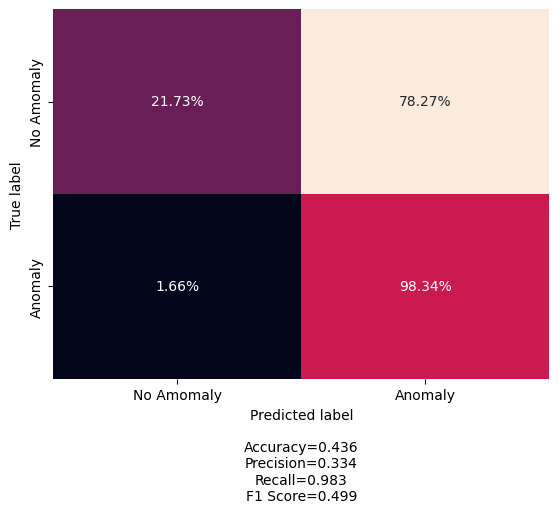

In [165]:
dataframe_data = dataframe_test_scaled.drop(columns=["anomaly", "description"])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_test_scaled.anomaly.values, kmeans_custom.predict(dataframe_data.values))),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [166]:
# plot.make_confusion_matrix(
#     confusion_matrix(dataframe_train_scaled.anomaly.values, kmeans_custom.labels_),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

### Isolation Forest

In [167]:
dataframe_X_train = dataframe_train_scaled.drop(columns=["anomaly", "description"])
dataframe_y_train = dataframe_train_scaled[["anomaly"]]
dataframe_X_test = dataframe_test_scaled.drop(columns=["anomaly", "description"])
dataframe_y_test = dataframe_test_scaled[["anomaly"]]

In [168]:
# dataframe_X = dataframe.drop(columns=["anomaly", "description"])
# dataframe_y = dataframe[["anomaly"]]

# X_train, X_test, y_train, y_test = train_test_split(
#                                                         dataframe_X.values, 
#                                                         dataframe_y.values.ravel(), 
#                                                         test_size=0.3, 
#                                                         random_state=SEED, 
#                                                         stratify=dataframe_y.values.ravel()
# )
# dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
# dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
# dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
# dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [169]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [170]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 2150 anomalies in test set.


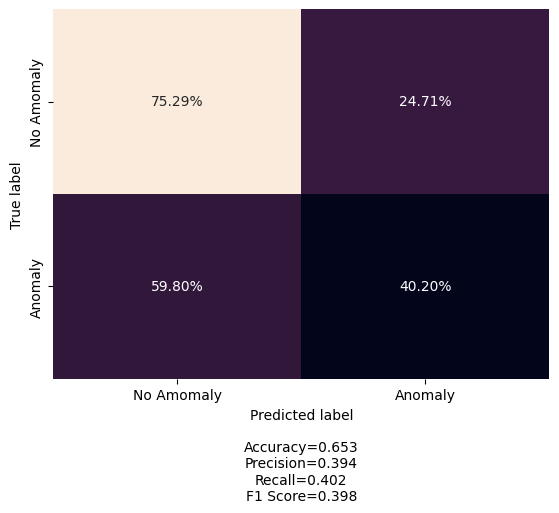

In [171]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [172]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [173]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 109 anomalies in test set.


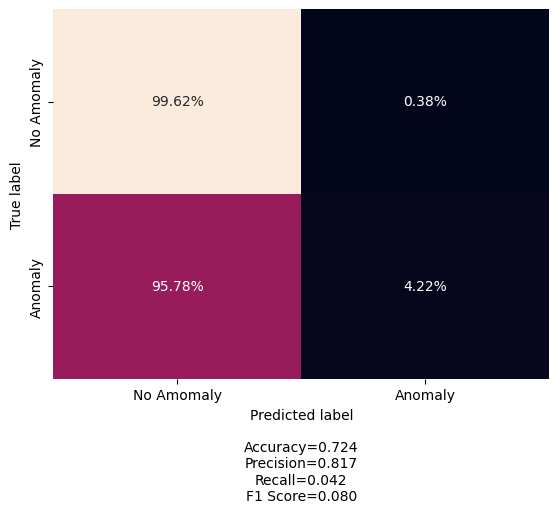

In [174]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [175]:
# dataframe_no_anomaly = dataframe[dataframe["anomaly"] == 0]
# dataframe_no_anomaly.drop(columns=["anomaly", "description"], inplace=True)

In [176]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     if i[0] == 0: continue
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

In [177]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
#     if idx == 0: continue  # Skip the normal class (0)
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [178]:
# for idx, (center, distance) in enumerate(zip(initial_centers, distances), 1):
#     tmp = dataframe_no_anomaly.apply(lambda row: np.linalg.norm(row - center), axis=1)
#     per = np.where(tmp < distance, 1, 0).sum() / tmp.shape[0] * 100
#     print(f"{idx}, {anomaly_ids[idx]}, Percentage within distance: {per:.2f}%")

In [179]:
# dataframe_all = dataframe.drop(columns=["anomaly", "description"])
# dataframe_all.shape

In [180]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

# for idx, name in anomaly_ids.items():
#     print(f"{idx}, {name}") 

In [181]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [182]:
# for idx1, name in anomaly_ids.items():
#     tmp = dataframe[dataframe["anomaly"] == idx]
#     tmp.drop(columns=["anomaly", "description"], inplace=True)

#     for idx2, (center, distance) in enumerate(zip(initial_centers, distances)):
#         tmp2 = tmp.apply(lambda row: np.linalg.norm(row - center), axis=1)
#         per = np.where(tmp2 < distance, 1, 0).sum() / tmp2.shape[0] * 100
#         print(f"{anomaly_ids[idx1]}, {anomaly_ids[idx2]}, Percentage within distance: {per:.2f}%")